<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
<b style="font-size: 35px">Загрузка данных и их первичная проверка</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Подключение необходимых библиотек</b></p>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Проверка корректности загрузки данных</b></p>
</div>

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12

df = pd.read_csv('../data/processed/hotels_clean.csv')

print(f"Shape: {df.shape}")
df.head()

Shape: (119385, 37)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,is_duplicated,total_nights,total_revenue,total_guests,booking_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,False,0,0.00,2,2014-07-24
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,0,Transient,0.00,0,0,Check-Out,2015-07-01,False,0,0.00,2,2013-06-24
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,False,1,75.00,1,2015-06-24
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,0,0,Transient,75.00,0,0,Check-Out,2015-07-02,False,1,75.00,1,2015-06-18
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,0,Transient,98.00,0,1,Check-Out,2015-07-03,False,2,196.00,2,2015-06-17


<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Проверка корректности столбцов и их типов</b></p>
</div>

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119385 entries, 0 to 119384
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   hotel                           119385 non-null  category
 1   is_canceled                     119385 non-null  int64   
 2   lead_time                       119385 non-null  int64   
 3   arrival_date_year               119385 non-null  int64   
 4   arrival_date_month              119385 non-null  category
 5   arrival_date_week_number        119385 non-null  int64   
 6   arrival_date_day_of_month       119385 non-null  int64   
 7   stays_in_weekend_nights         119385 non-null  int64   
 8   stays_in_week_nights            119385 non-null  int64   
 9   adults                          119385 non-null  int64   
 10  children                        119385 non-null  int64   
 11  babies                          119385 non-null  int64   
 12  meal         

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Преобразование типов</b><br>
    Так как категориальные столбцы были сохранены в простом csv файле, то они загрузились в виде str. Далее они сново будут преобразованы в котегориальных тип</p>
</div>

In [3]:
categorical_cols = [
    'hotel', 'arrival_date_month', 'meal', 'market_segment',
    'distribution_channel', 'customer_type', 'deposit_type',
    'reservation_status', 'reserved_room_type', 'assigned_room_type',
    'country'
]

df[categorical_cols] = df[categorical_cols].astype('category')

MONTHS_ORDER = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=MONTHS_ORDER,
    ordered=True
)

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Просмотр первичной статистики</b><br>
    Далее будет представлена информация о каждом из столбцов: количество значений, самое частое значение, ср. значение, дисперсия, квартили, минимальное и максимальное</p>
</div>

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119385,2,City Hotel,79327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119385.00,NaN,NaN,NaN,0.37,0.48,0.00,0.00,0.00,1.00,1.00
lead_time,119385.00,NaN,NaN,NaN,104.01,106.86,0.00,18.00,69.00,160.00,737.00
arrival_date_year,119385.00,NaN,NaN,NaN,2016.16,0.71,2015.00,2016.00,2016.00,2017.00,2017.00
arrival_date_month,119385,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119385.00,NaN,NaN,NaN,27.17,13.61,1.00,16.00,28.00,38.00,53.00
arrival_date_day_of_month,119385.00,NaN,NaN,NaN,15.80,8.78,1.00,8.00,16.00,23.00,31.00
stays_in_weekend_nights,119385.00,NaN,NaN,NaN,0.93,1.00,0.00,0.00,1.00,2.00,19.00
stays_in_week_nights,119385.00,NaN,NaN,NaN,2.50,1.91,0.00,1.00,2.00,3.00,50.00
adults,119385.00,NaN,NaN,NaN,1.86,0.58,0.00,2.00,2.00,2.00,55.00


<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Все данные были загружены корректно</b>
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
<b style="font-size: 35px">Проверка на корреляцию признаков</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Далее будут определены признаки, имеющие сильную корреляцию</b><br>
        Это необходимо для того, чтобы уменьшить размерность данных для анализа и не потерять полезную информацию. Для нахождения таких признаков будет использоваться метод "Корреляция Спирмена", т.к. много числовых признаков "скошены" вправо, что корректно обработает данный метод
    </p>
</div>

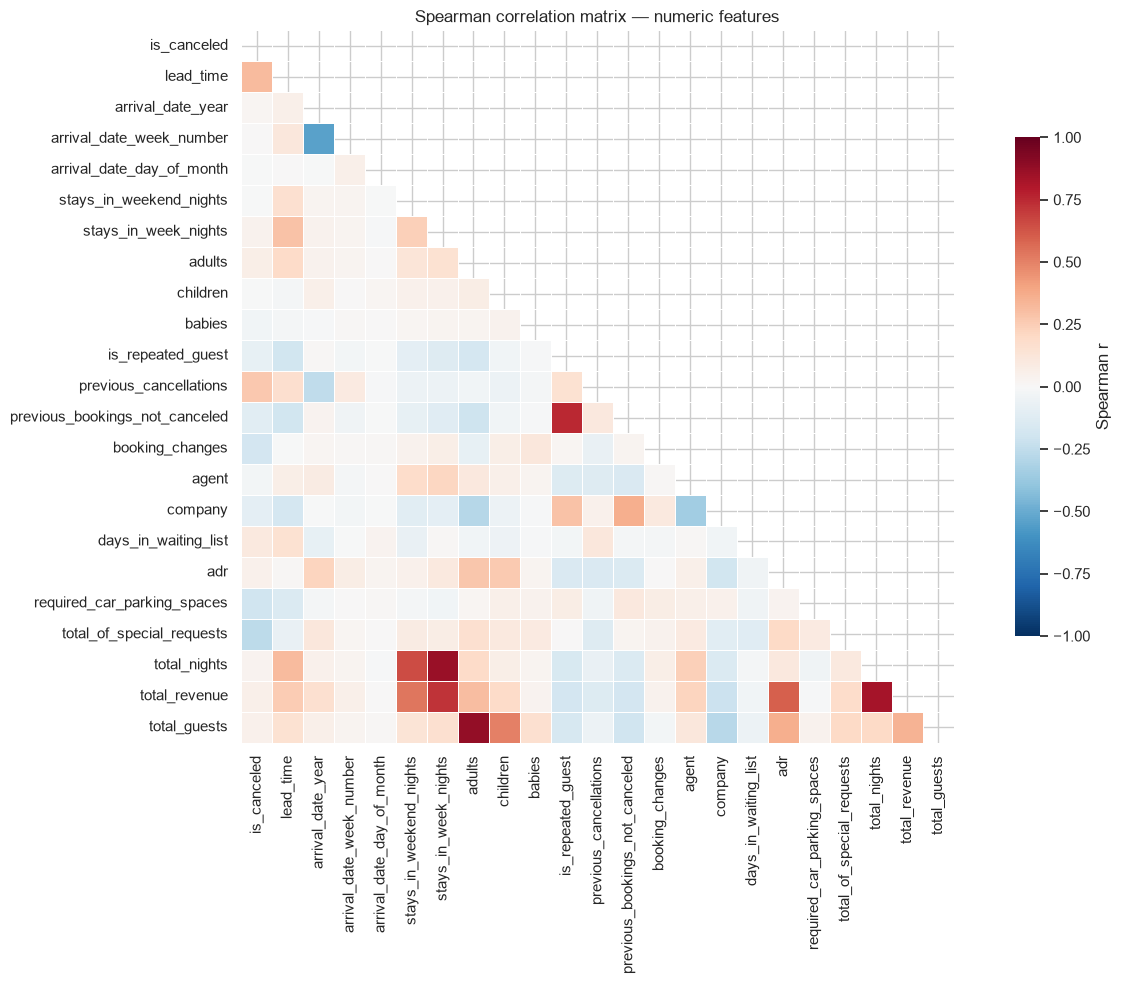

In [6]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr(method='spearman')

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7, 'label': 'Spearman r'}
)
plt.title('Spearman correlation matrix — numeric features')
plt.tight_layout()
plt.show()

In [7]:
pairs = (
    corr.where(~np.eye(len(corr), dtype=bool))  # drop diagonal
        .stack()
        .reset_index()
)
pairs.columns = ['feature_1', 'feature_2', 'r']

pairs['key'] = pairs.apply(lambda x: tuple(sorted([x['feature_1'], x['feature_2']])), axis=1)
pairs = pairs.drop_duplicates('key').drop(columns='key')

strong_pairs = (
    pairs[pairs['r'].abs() > 0.5]
    .sort_values('r', key=lambda s: s.abs(), ascending=False)
    .reset_index(drop=True)
)
strong_pairs

,feature_1,feature_2,r
0,adults,total_guests,0.88
1,stays_in_week_nights,total_nights,0.87
2,total_nights,total_revenue,0.83
3,is_repeated_guest,previous_bookings_not_canceled,0.76
4,stays_in_week_nights,total_revenue,0.72
5,stays_in_weekend_nights,total_nights,0.66
6,adr,total_revenue,0.59
7,arrival_date_year,arrival_date_week_number,-0.54
8,stays_in_weekend_nights,total_revenue,0.54
9,children,total_guests,0.51


<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Корреляционная матрица</b>
    Всего были полученыы 10 пар с |r| > 0.5:
    <ul>
        <li>8 пар - производные признаки (total_nights, total_guests, total_revenue и их компоненты). Это подтверждает корректность признаки, они линейно зависимы. При дальнейшем анализе можно использовать только производные или их компоненты</li>
        <li>1 пара - содержательная: is_repeated_guest <-> previous_bookings_not_canceled (r = 0.76). Гость, у которого есть история неотменённых броней, помечается как повторный и чаще не отменяет бронь.</li>
        <li>1 пара - артефакт датасета: arrival_date_year <-> arrival_date_week_number (r = -0.54). Данные охватывают неполные годы, распределение недель смещается.
    </ul>
    Остальные признаки имеют достаточно малую корреляцию и сказать о их зависимости между собой нельзя
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
<b style="font-size: 35px">Просмотр общей статистики</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Ключевые метрики по всем данным</b><br>
    </p>
</div>

In [8]:
metrics = {
    'cancellation_rate': df['is_canceled'].mean(),
    'adr_mean': df['adr'].mean(),
    'adr_median': df['adr'].median(),
    'nights_mean': df['total_nights'].mean(),
    'nights_median': df['total_nights'].median(),
    'lead_time_mean': df['lead_time'].mean(),
    'lead_time_median': df['lead_time'].median(),
    'guests_mean': df['total_guests'].mean(),
    'guests_median': df['total_guests'].median(),
}

df_ok = df[df['is_canceled'] == 0]

metrics_ok = {
    'cancellation_rate': df_ok['is_canceled'].mean(),
    'adr_mean': df_ok['adr'].mean(),
    'adr_median': df_ok['adr'].median(),
    'nights_mean': df_ok['total_nights'].mean(),
    'nights_median': df_ok['total_nights'].median(),
    'lead_time_mean': df_ok['lead_time'].mean(),
    'lead_time_median': df_ok['lead_time'].median(),
    'guests_mean': df_ok['total_guests'].mean(),
    'guests_median': df_ok['total_guests'].median(),
}




tables_html = ""

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b><i>Статистика по всем броням:</i></b><br><br>"
    f"{pd.DataFrame(
        [(k, round(v, 2)) for k, v in metrics.items()],
        columns=['metric', 'value']
    ).to_html()}"
    f"</div>"
          )

tables_html += (
    f"<div style='display:inline-block;vertical-align:top; margin-right:100px; text-align: center'>"
    f"<b><i>Статистика состоявшимся броням:</i></b><br><br>"
    f"{pd.DataFrame(
        [(k, round(v, 2)) for k, v in metrics_ok.items()],
        columns=['metric', 'value']
    ).to_html()}"
    f"</div>"
          )

display(HTML(tables_html))

,metric,value
0,cancellation_rate,0.37
1,adr_mean,101.79
2,adr_median,94.56
3,nights_mean,3.43
4,nights_median,3.00
5,lead_time_mean,104.01
6,lead_time_median,69.00
7,guests_mean,1.97
8,guests_median,2.00
,metric,value


<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Распределение lead_time и adr по отменённым и неотменённым группам брони</b><br>
    </p>
</div>

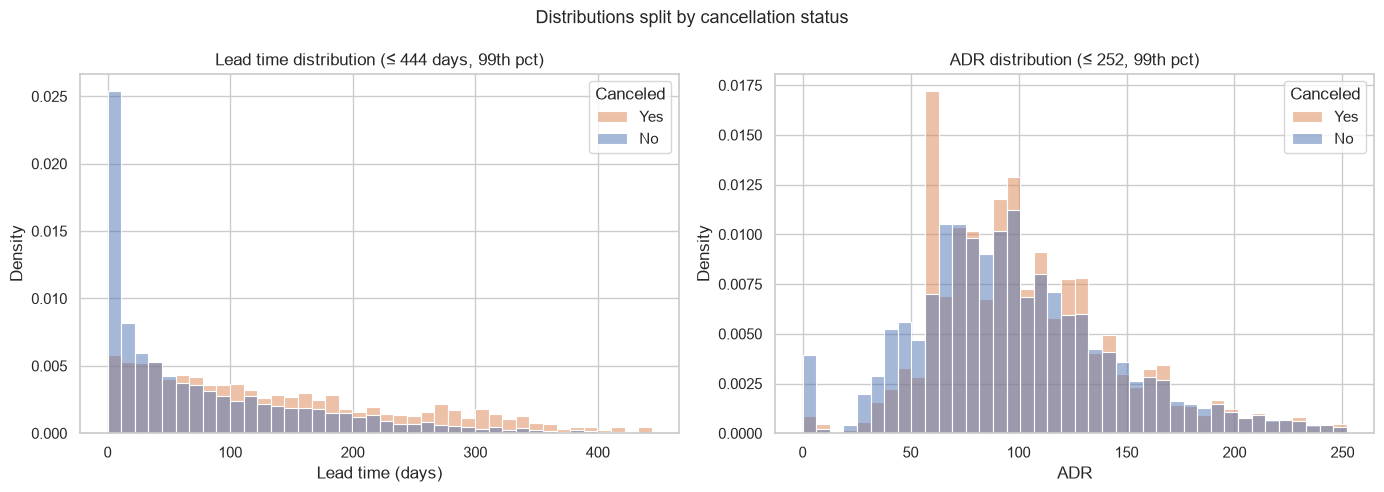

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_lead = df['lead_time'].quantile(0.99)
sns.histplot(
    data=df[df['lead_time'] <= p99_lead],
    x='lead_time',
    hue='is_canceled',
    bins=40,
    stat='density',
    common_norm=False,
    ax=axes[0]
)
axes[0].set_title(f'Lead time distribution (≤ {p99_lead:.0f} days, 99th pct)')
axes[0].set_xlabel('Lead time (days)')
axes[0].set_ylabel('Density')
axes[0].legend(title='Canceled', labels=['Yes', 'No'])

p99_adr = df['adr'].quantile(0.99)
sns.histplot(
    data=df[df['adr'] <= p99_adr],
    x='adr',
    hue='is_canceled',
    bins=40,
    stat='density',
    common_norm=False,
    ax=axes[1]
)
axes[1].set_title(f'ADR distribution (≤ {p99_adr:.0f}, 99th pct)')
axes[1].set_xlabel('ADR')
axes[1].set_ylabel('Density')
axes[1].legend(title='Canceled', labels=['Yes', 'No'])

plt.suptitle('Distributions split by cancellation status', fontsize=13)
plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Наблюдения</b><br>
    Общая доля отмен составляет 37%, что описывает достаточно большую проблему. <br>
    По стостоявшимся броням:
    <ul>
        <li>Средний ADR - 100, медиана - 92.5. Есть дорогие брони, которые смещают adr вправо</li>
        <li>Средняя длительность - 3.4 ночи, медиана - 3, также есть смещение вправо</li>
        <li>Средний lead time - 80 дней, медиана - 45. Медиана вдвое ниже средней - признак c сильной правосторонней скошенности</li>
    </ul><br>
    Сравнение отменённых и состоявшихся броней (визуализация):
    <ul>
        <li>Lead time: распределение отменённых смещено вправо. Медиана по всем броням - 69 дней против 45 у состоявшихся. Чем раньше бронируют, тем выше шанс отмены</li>
        <li>ADR: отменённые брони концентрируются в низком ценовом диапазоне, состоявшиеся распределяются равномернее</li>
    </ul>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Метрики неоменённых броней</b><br>
    </p>
</div>

In [10]:
df_ok = df[df['is_canceled'] == 0]

revenue_metrics = {
    'Сумма total_revenue': df_ok['total_revenue'].sum(),
    'Количество броней': len(df_ok),
    'Средняя выручку от брони': df_ok['total_revenue'].mean(),
    'Медиана выручки от брони': df_ok['total_revenue'].median(),
    '0.9 квартиль выручки': df_ok['total_revenue'].quantile(0.90),
    '0.99 квартиль выручки': df_ok['total_revenue'].quantile(0.99),
}

pd.DataFrame(
    [(k, round(v, 2)) for k, v in revenue_metrics.items()],
    columns=['metric', 'value']
)

,metric,value
0,Сумма total_revenue,25995870.31
1,Количество броней,75163.00
2,Средняя выручку от брони,345.86
3,Медиана выручки от брони,259.20
4,0.9 квартиль выручки,706.51
5,0.99 квартиль выручки,1608.68


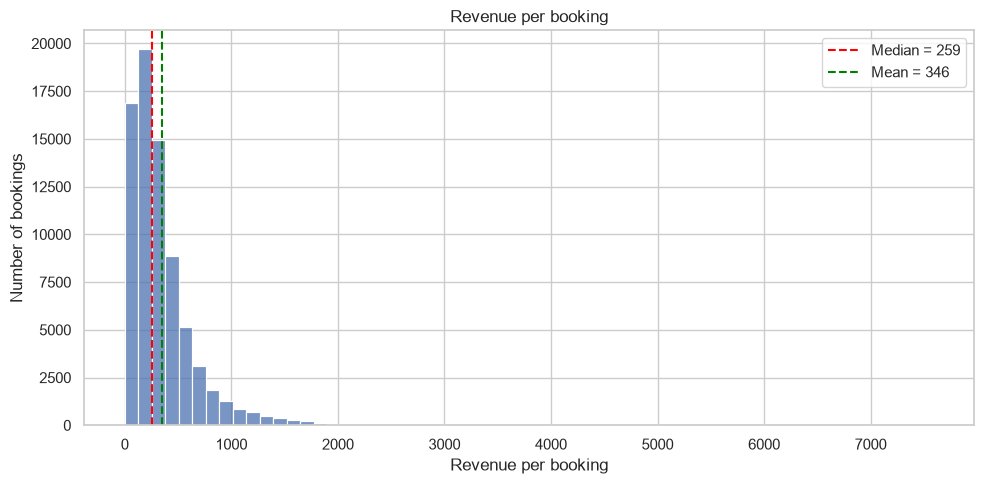

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_ok,
    x='total_revenue',
    bins=60,
    ax=ax
)
ax.set_title('Revenue per booking')
ax.set_xlabel('Revenue per booking')
ax.set_ylabel('Number of bookings')
ax.axvline(df_ok['total_revenue'].median(), color='red', linestyle='--',
           label=f'Median = {df_ok["total_revenue"].median():.0f}')
ax.axvline(df_ok['total_revenue'].mean(), color='green', linestyle='--',
           label=f'Mean = {df_ok["total_revenue"].mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Наблюдения</b><br>
    Выручка по состоявшимся броням:
    <ul>
        <li>За период датасета состоялось 75 163 брони. Суммарная выручка от проживания - ~26,0 млн</li>
    </ul>
    Выручка на одну бронь:
    <ul>
        <li>Средняя - 346</li>
        <li>Медиана - 259</li>
        <li>90-й перцентиль - 707</li>
        <li>99-й перцентиль - 1 609</li>
    </ul>
    Распределение сильно скошено вправо: медиана почти в 1.3 раза ниже среднего. Большинство броней - короткие и недорогие, но есть "хвост" из дорогих и длинных.
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Парето</b><br>
    </p>
</div>

In [12]:
df_ok_sorted = df_ok.sort_values('total_revenue', ascending=False)
top_10_pct_count = int(len(df_ok_sorted) * 0.10)
top_10_pct_revenue = df_ok_sorted.head(top_10_pct_count)['total_revenue'].sum()
total_revenue = df_ok_sorted['total_revenue'].sum()
share_top_10 = top_10_pct_revenue / total_revenue * 100

print(f"Топ 10%  (n = {top_10_pct_count:,}) "
      f"генерируют {share_top_10:.1f}% выручки")
print(f"Остальные 90% броней (n = {len(df_ok_sorted) - top_10_pct_count:,}) "
      f"генерируют {100 - share_top_10:.1f}% выручки")

Топ 10%  (n = 7,516) генерируют 31.6% выручки
Остальные 90% броней (n = 67,647) генерируют 68.4% выручки


<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Наблюдения</b><br>
    Концентрация выручки в 10% является обычным явлением и в данной ситуации не сильно превосходит остальные 90%
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Структура по типу питания</b><br>
    </p>
</div>

In [13]:
meal_all = (
    df.groupby('meal', observed=True)
      .agg(
          bookings=('is_canceled', 'size'),
          cancel_rate=('is_canceled', 'mean'),
          repeat_share=('is_repeated_guest', 'mean'),
      )
)

meal_ok = (
    df_ok.groupby('meal', observed=True)
         .agg(
             bookings_ok=('is_canceled', 'size'),
             revenue_total=('total_revenue', 'sum'),
         )
)

meal_stats = (
    meal_all.join(meal_ok)
            .assign(
                bookings_share=lambda x: x['bookings'] / x['bookings'].sum() * 100,
                revenue_share=lambda x: x['revenue_total'] / x['revenue_total'].sum() * 100,
            )
            .round(3)
            .sort_values('bookings', ascending=False)
)

meal_stats

,bookings,cancel_rate,repeat_share,bookings_ok,revenue_total,bookings_share,revenue_share
meal,,,,,,,
BB,92305,0.37,0.04,57797,18670590.64,77.32,71.82
HB,14463,0.34,0.01,9479,5034459.67,12.12,19.37
SC,10650,0.37,0.01,6684,1677654.02,8.92,6.45
Undefined,1169,0.24,0.03,883,381490.80,0.98,1.47
FB,798,0.60,0.01,320,231675.18,0.67,0.89


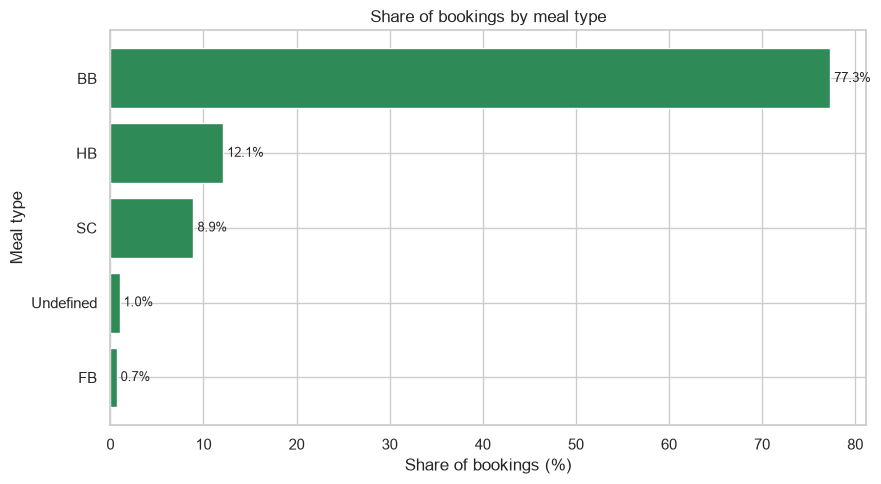

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

meal_plot = meal_stats.sort_values('bookings_share', ascending=True)
ax.barh(
    meal_plot.index.astype(str),
    meal_plot['bookings_share'],
    color='seagreen'
)
ax.set_title('Share of bookings by meal type')
ax.set_xlabel('Share of bookings (%)')
ax.set_ylabel('Meal type')

for i, v in enumerate(meal_plot['bookings_share']):
    ax.text(v, i, f' {v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Наблюдения</b><br>
    <ul>
        <li>BB (Bed & Breakfast) - доминирующий тариф: 77.3% броней, но только 71.8% выручки. Доля выручки ниже доли броней: BB - самый дешёвый тариф в пересчёте на бронь. Отмена 37% - на уровне среднего</li>
        <li>HB (Half Board) - 12.1% броней и 19.4% выручки - заметно выше своей доли. Это самый дорогой тариф. Отмена 34% - ниже средней</li>
        <li>SC (Self Catering) - 8.9% броней, 6.5% выручки. Самый дешёвый тариф. Отмена 37%</li>
        <li>Undefined - 1.0% броней. Низкая доля отмен (24%)</li>
        <li>FB (Full Board) - 0.7% броней (798 шт.), но доля отмен 60% - самая высокая среди всех типов питания</li>
    </ul>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Метрики по маркетинговым сегментам и каналам продаж</b><br>
    </p>
</div>

In [15]:
seg_all = (
    df.groupby('market_segment', observed=True)
      .agg(
          bookings=('is_canceled', 'size'),
          cancel_rate=('is_canceled', 'mean'),
          adr_mean=('adr', 'mean'),
          nights_mean=('total_nights', 'mean'),
          repeat_share=('is_repeated_guest', 'mean'),
      )
)

seg_ok = (
    df_ok.groupby('market_segment', observed=True)
      .agg(
          bookings_ok=('is_canceled', 'size'),
          revenue_total=('total_revenue', 'sum'),
          revenue_per_booking=('total_revenue', 'mean'),
      )
)

seg_stats = (
    seg_all.join(seg_ok)
        .assign(revenue_share=lambda x: x['revenue_total'] / x['revenue_total'].sum() * 100)
        .round(2)
        .sort_values('bookings', ascending=False)
)
seg_stats

,bookings,cancel_rate,adr_mean,nights_mean,repeat_share,bookings_ok,revenue_total,revenue_per_booking,revenue_share
market_segment,,,,,,,,,
Online TA,56476,0.37,117.20,3.57,0.01,35737.00,13714232.52,383.75,52.76
Offline TA/TO,24217,0.34,87.13,3.90,0.02,15908.00,5659554.58,355.77,21.77
Groups,19810,0.61,79.48,2.99,0.01,7713.00,1869156.56,242.34,7.19
Direct,12606,0.15,115.45,3.21,0.06,10672.00,4099618.57,384.15,15.77
Corporate,5294,0.19,69.35,2.09,0.28,4302.00,577627.19,134.27,2.22
Complementary,743,0.13,2.89,1.65,0.31,646.00,4812.53,7.45,0.02
Aviation,237,0.22,100.14,3.61,0.27,185.00,70868.36,383.07,0.27
Undefined,2,1.00,15.00,1.50,0.00,NaN,NaN,NaN,NaN


In [16]:
ch_all = (
    df.groupby('distribution_channel', observed=True)
      .agg(
          bookings=('is_canceled', 'size'),
          cancel_rate=('is_canceled', 'mean'),
          adr_mean=('adr', 'mean'),
          nights_mean=('total_nights', 'mean'),
          repeat_share=('is_repeated_guest', 'mean'),
      )
)

ch_ok = (
    df_ok.groupby('distribution_channel', observed=True)
      .agg(
          bookings_ok=('is_canceled', 'size'),
          revenue_total=('total_revenue', 'sum'),
          revenue_per_booking=('total_revenue', 'mean'),
      )
)

ch_stats = (
    ch_all.join(ch_ok)
        .assign(revenue_share=lambda x: x['revenue_total'] / x['revenue_total'].sum() * 100)
        .round(2)
        .sort_values('bookings', ascending=False)
)
ch_stats

,bookings,cancel_rate,adr_mean,nights_mean,repeat_share,bookings_ok,revenue_total,revenue_per_booking,revenue_share
distribution_channel,,,,,,,,,
TA/TO,97867,0.41,103.24,3.54,0.01,57717,20809393.45,360.54,80.05
Direct,14644,0.17,106.66,3.19,0.06,12087,4325305.48,357.85,16.64
Corporate,6676,0.22,69.32,2.38,0.24,5202,827599.92,159.09,3.18
GDS,193,0.19,120.55,1.96,0.02,156,33007.96,211.59,0.13
Undefined,5,0.80,46.24,3.40,0.00,1,563.50,563.50,0.00


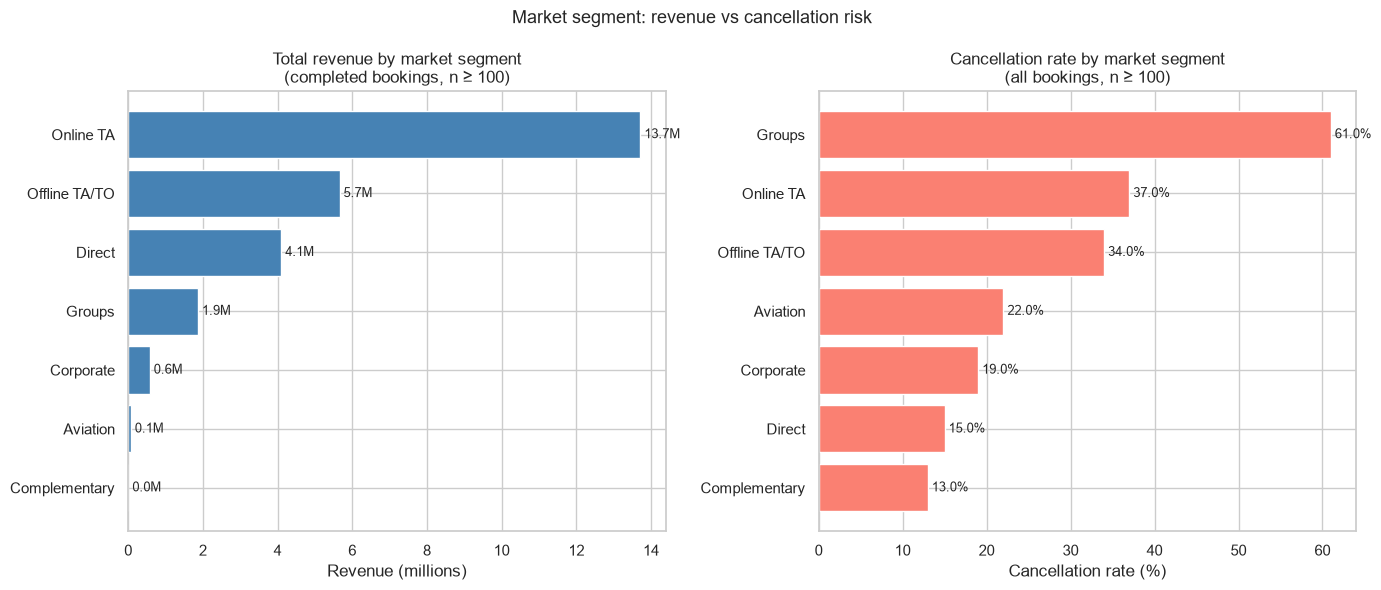

In [17]:
MIN_BOOKINGS = 100

seg_plot = seg_stats[seg_stats['bookings'] >= MIN_BOOKINGS].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

seg_sorted_rev = seg_plot.sort_values('revenue_total', ascending=True)
axes[0].barh(
    seg_sorted_rev.index.astype(str),
    seg_sorted_rev['revenue_total'] / 1_000_000,
    color='steelblue'
)
axes[0].set_title(f'Total revenue by market segment\n(completed bookings, n ≥ {MIN_BOOKINGS})')
axes[0].set_xlabel('Revenue (millions)')
for i, v in enumerate(seg_sorted_rev['revenue_total'] / 1_000_000):
    axes[0].text(v, i, f' {v:.1f}M', va='center', fontsize=9)

seg_sorted_cancel = seg_plot.sort_values('cancel_rate', ascending=True)
axes[1].barh(
    seg_sorted_cancel.index.astype(str),
    seg_sorted_cancel['cancel_rate'] * 100,
    color='salmon'
)
axes[1].set_title(f'Cancellation rate by market segment\n(all bookings, n ≥ {MIN_BOOKINGS})')
axes[1].set_xlabel('Cancellation rate (%)')
for i, v in enumerate(seg_sorted_cancel['cancel_rate'] * 100):
    axes[1].text(v, i, f' {v:.1f}%', va='center', fontsize=9)

plt.suptitle('Market segment: revenue vs cancellation risk', fontsize=13)
plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Наблюдения</b><br>
    Статистика по маркетинговым сигментам:
    <ul>
        <li>Online TA - крупнейший сегмент: 47% броней и 53% выручки. Средний ADR - 117, отмена - 37%. Доля повторных гостей - 1%.</li>
        <li>Offline TA/TO - 20% броней, 22% выручки. ADR - 87, отмена 34%</li>
        <li>Groups - 17% броней, но всего 7% выручки. Отмена 61% - самый высокий показатель. ADR низкий - 79, длительность ~3 ночи</li>
        <li>Direct - 11% броней и 16% выручки. Отмена всего 15% - вдвое ниже общей доли отмены. Доля повторных гостей - 6%. Это надёжный и «дорогой» канал</li>
        <li>Corporate - 4% броней, 2% выручки. ADR самый низкий среди платных - 69, но repeat share 28% - самый лояльный сегмент</li>
        <li>Complementary - 743 брони с ADR ≈ 3. Это бесплатные/комплиментарные размещения. В выручке не играют роли, но интересны как категория</li>
        <li>Aviation - 237 броней, ADR 100, отмена 22%. Мелкий, но «хороший» сегмент</li>
        <li>Undefined - 2 брони, что мало для каких либо выводов</li>
    </ul>
    Статистика по каналам продаж:
    <ul>
        <li>TA/TO - 82% броней, 80% выручки, отмена 41%. Через данный канал идёт почти весь бизнес, но также большой процент отмен</li>
        <li>Direct - 12% броней, 17% выручки, отмена 17%. Более дорогой и надёжный канал, но достаточно маленький</li>
        <li>Corporate - 6% броней, 3% выручки, отмена 22%, доля повторных гостей 24%. Лояльный, но маленький.</li>
        <li>GDS - 193 брони, отмена 19%, ADR самый высокий - 121. Очень маленький канал.</li>
    </ul>
    <b><i>
    Бизнес сильно сконцентрирован в TA/TO (80% выручки) и Online TA (53%). Перебои в одном канале могут ударить по всему.<br>
    Direct-канал - лучший по надёжности: доля отмен вдвое ниже, чем у TA/TO, при сравнимом ADR. При этом у него только 17% выручки.<br>
    Groups - самый рискованный сегмент (61% отмен) при низком ADR.<br>
    Corporate - лояльный (28% повторных), но недорогой.</b></i>
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
<b style="font-size: 35px">Сезонность и динамика</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Первый и последний месяц в году</b><br>
    </p>
</div>

In [18]:
df.groupby('arrival_date_year', observed=True).agg(
    n=('is_canceled', 'size')
).assign(
    first_month=df.groupby('arrival_date_year', observed=True)['arrival_date_month'].min(),
    last_month=df.groupby('arrival_date_year', observed=True)['arrival_date_month'].max()
)

,n,first_month,last_month
arrival_date_year,,,
2015,21994,July,December
2016,56705,January,December
2017,40686,January,August


<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Распределение количество броней по годам и месяцам</b><br>
    </p>
</div>

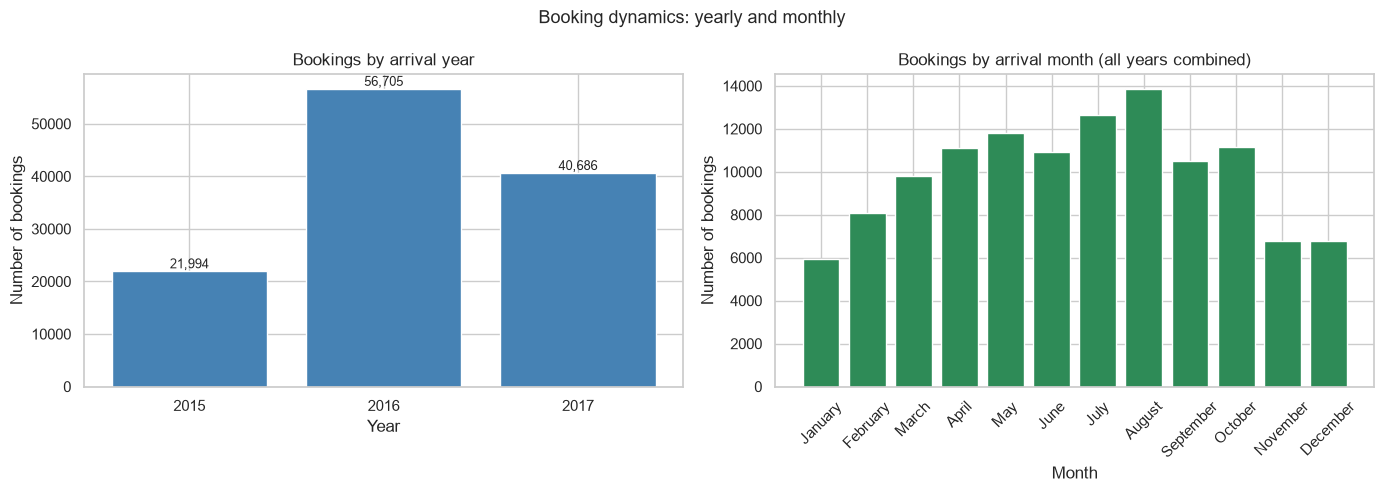

In [19]:
bookings_by_year = df.groupby('arrival_date_year', observed=True).size()
bookings_by_month = df.groupby('arrival_date_month', observed=True).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    bookings_by_year.index.astype(str),
    bookings_by_year.values,
    color='steelblue'
)
axes[0].set_title('Bookings by arrival year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of bookings')
for i, v in enumerate(bookings_by_year.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

axes[1].bar(
    bookings_by_month.index.astype(str),
    bookings_by_month.values,
    color='seagreen'
)
axes[1].set_title('Bookings by arrival month (all years combined)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of bookings')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Booking dynamics: yearly and monthly', fontsize=13)
plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Наблюдения</b><br>
    Бронирования по годам:
    <ul>
        <li>2015: 21 994 брони - данные начинаются с июля</li>
        <li>2016: 56 705 броней - единственный полный год</li>
        <li>2017: 40 686 броней - данные обрываются в середине года (август).</li>
    </ul>
        Бронирования по месяцам:
    <ul>
        <li>Пик - август</li>
        <li>Спад - январь-февраль и ноябрь-декабрь</li>
    </ul> 
    Мы видим обычную картину для сезонного туристического бизнеса: летний пик и осенний + зимний спад.<br>
    <b><i>
        Стоит отметить, что при агрегации по всем годам смешивается неполные годы с полным (2016). Месячные пики всё равно видны, но абсолютные значения смещены.
    </b></i>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Сравнение количества броней по месяцам</b><br>
    </p>
</div>

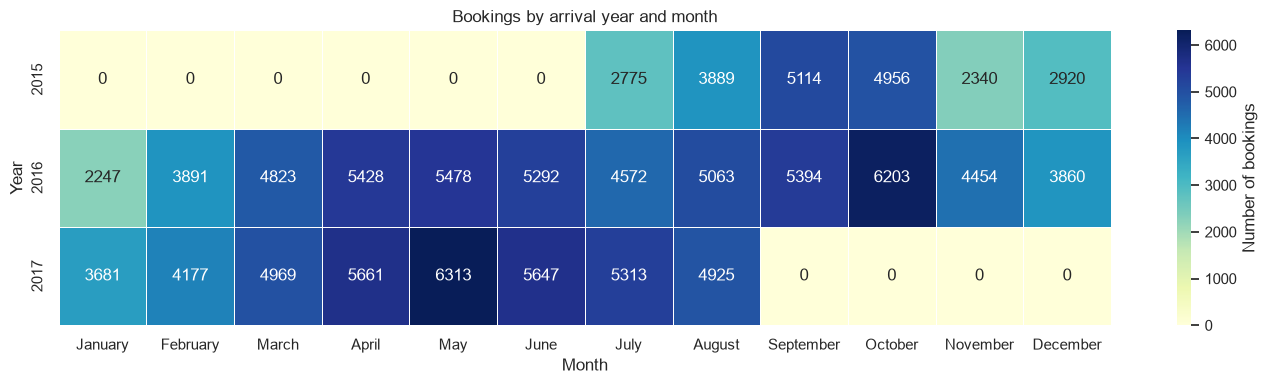

In [20]:
pivot_year_month = df.pivot_table(
    index='arrival_date_year',
    columns='arrival_date_month',
    values='is_canceled',
    aggfunc='size',
    observed=True,
    fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot_year_month,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Number of bookings'},
    linewidths=0.5,
    ax=ax
)
ax.set_title('Bookings by arrival year and month')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Наблюдения</b><br>
    <ul>
        <li>Сезонные пики: в каждом году август - максимум (2015: 3 889; 2016: 5 063; 2017: 4 925). В 2016 и 2017 также заметен вторичный пик в мае (5 478 и 6 313 соответственно) и октябре (2016: 6 203 - абсолютный максимум месяца в датасете)</li>
        <li>Спады: январь–февраль стабильно ниже соседних месяцев во всех трёх годах</li>
    </ul>
    Можно заметить, что сезонный профиль устойчив между годами (летний пик, зимний спад)
</div>

<div style = "border-left: 5px solid orange; padding-left: 25px; margin: 10px">
<b style="font-size: 35px">Сравнение городского и загородного отелей</b>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Сравнение основных характеристик</b><br>
    </p>
</div>

In [21]:
hotel_all = (
    df.groupby('hotel', observed=True)
      .agg(
          bookings=('is_canceled', 'size'),
          cancel_rate=('is_canceled', 'mean'),
          repeat_share=('is_repeated_guest', 'mean'),
          guests_mean=('total_guests', 'mean'),
      )
)

# (b) Completed bookings only: ADR, nights, lead_time, revenue
hotel_ok = (
    df_ok.groupby('hotel', observed=True)
         .agg(
             bookings_ok=('is_canceled', 'size'),
             adr_mean=('adr', 'mean'),
             adr_median=('adr', 'median'),
             nights_mean=('total_nights', 'mean'),
             nights_median=('total_nights', 'median'),
             lead_time_mean=('lead_time', 'mean'),
             lead_time_median=('lead_time', 'median'),
             revenue_total=('total_revenue', 'sum'),
             revenue_per_booking=('total_revenue', 'mean'),
         )
)

hotel_stats = (
    hotel_all.join(hotel_ok)
             .assign(revenue_share=lambda x: x['revenue_total'] / x['revenue_total'].sum() * 100)
             .round(2)
)
hotel_stats

,bookings,cancel_rate,repeat_share,guests_mean,bookings_ok,adr_mean,adr_median,nights_mean,nights_median,lead_time_mean,lead_time_median,revenue_total,revenue_per_booking,revenue_share
hotel,,,,,,,,,,,,,,
City Hotel,79327,0.42,0.03,1.95,46226,105.75,99.90,2.92,3.00,80.71,50.00,14393956.28,311.38,55.37
Resort Hotel,40058,0.28,0.04,2.01,28937,90.79,72.00,4.14,3.00,78.83,38.00,11601914.03,400.94,44.63


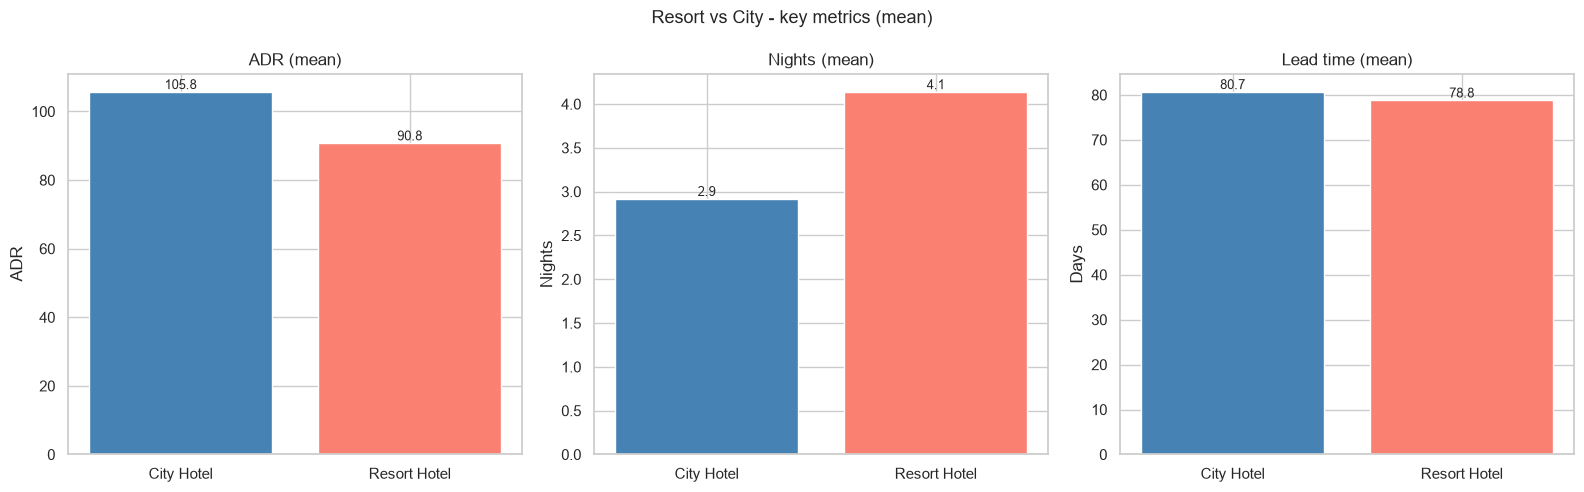

In [22]:
metrics_plot = [
    ('adr_mean',       'ADR (mean)',           'ADR'),
    ('nights_mean',    'Nights (mean)',        'Nights'),
    ('lead_time_mean', 'Lead time (mean)',     'Days'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title, ylabel) in zip(axes, metrics_plot):
    values = hotel_stats[col]
    plot_values = values
    bars = ax.bar(plot_values.index.astype(str), plot_values.values,
                  color=['steelblue', 'salmon'])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for i, v in enumerate(plot_values.values):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Resort vs City - key metrics (mean)', fontsize=13)
plt.tight_layout()
plt.show()

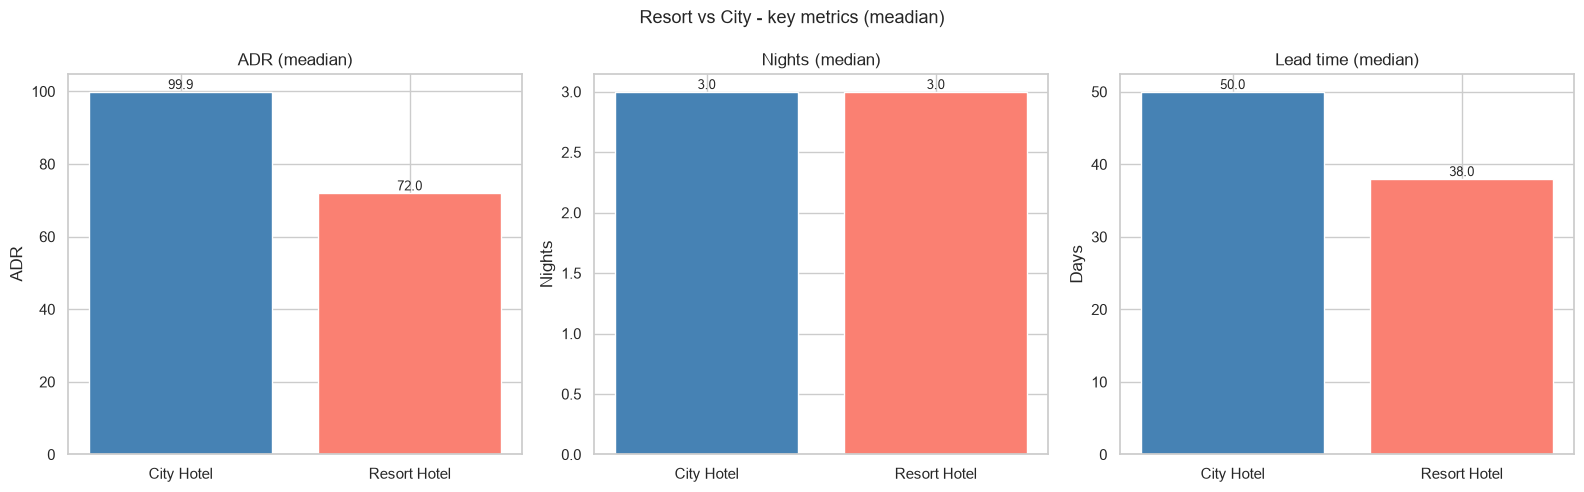

In [23]:
metrics_plot = [
    ('adr_median',       'ADR (meadian)',           'ADR'),
    ('nights_median',    'Nights (median)',        'Nights'),
    ('lead_time_median', 'Lead time (median)',     'Days'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title, ylabel) in zip(axes, metrics_plot):
    values = hotel_stats[col]
    plot_values = values
    bars = ax.bar(plot_values.index.astype(str), plot_values.values,
                  color=['steelblue', 'salmon'])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for i, v in enumerate(plot_values.values):
        ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Resort vs City - key metrics (meadian)', fontsize=13)
plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px">
<b style="font-size: 18px">Наблюдения</b><br>
    <ul>
        <li>City дороже Resort за ночь: медианный ADR 99.9 и 72.0 соответственно, разрыв больше, чем по средним (где Resort тянет вверх хвост дорогих броней).</li>
        <li>Vедианная длительность одинакова - 3.0 ночи в обоих отелях. Разница в средних (2.9 и 4.1) создаётся длинным хвостом: у Resort есть сегмент проживаний 7+ ночей, у City его почти нет.</li>
        <li>Городской отель в медиане бронируют за большее время, что может быть связано с большим спросом</li>
    </ul>
</div>

<div style = "border-left: 5px solid blue; padding-left: 25px; margin: 10px">
    <p style="font-size: 16px"><b>Сравнение стоимости</b><br>
    </p>
</div>

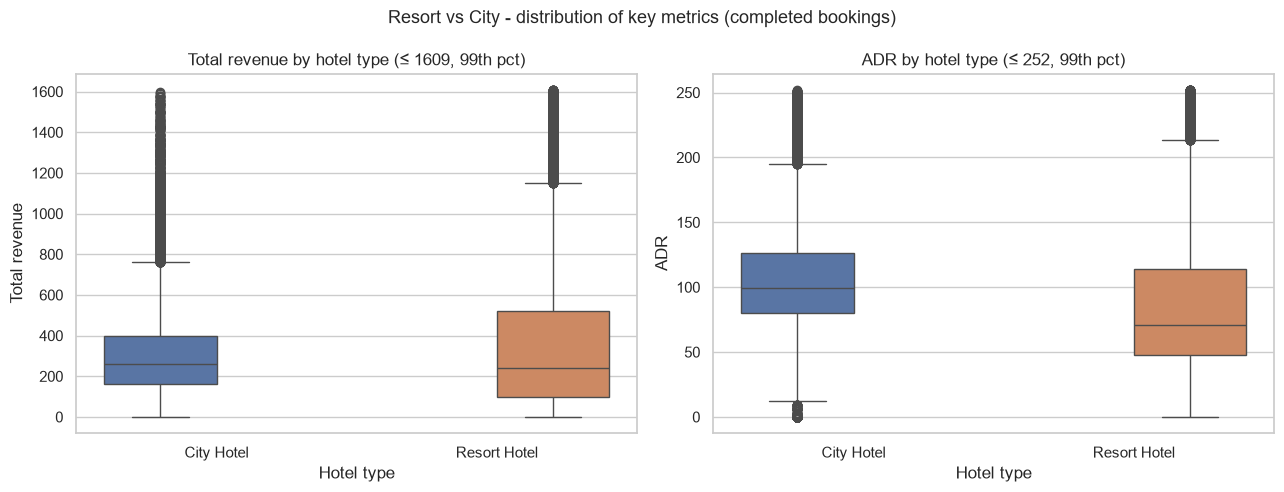

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

p99_lead = df_ok['total_revenue'].quantile(0.99)
sns.boxplot(
    data=df_ok[df_ok['total_revenue'] <= p99_lead],
    x='hotel', y='total_revenue',
    hue='hotel', legend=False,
    ax=axes[0], palette='deep'
)
axes[0].set_title(f'Total revenue by hotel type (≤ {p99_lead:.0f}, 99th pct)')
axes[0].set_xlabel('Hotel type')
axes[0].set_ylabel('Total revenue')

p99_adr = df_ok['adr'].quantile(0.99)
sns.boxplot(
    data=df_ok[df_ok['adr'] <= p99_adr],
    x='hotel', y='adr',
    hue='hotel', legend=False,
    ax=axes[1], palette='deep'
)
axes[1].set_title(f'ADR by hotel type (≤ {p99_adr:.0f}, 99th pct)')
axes[1].set_xlabel('Hotel type')
axes[1].set_ylabel('ADR')

plt.suptitle('Resort vs City - distribution of key metrics (completed bookings)', fontsize=13)
plt.tight_layout()
plt.show()

<div style = "border-left: 5px solid green; padding-left: 25px">
    <b style="font-size: 18px">Наблюдения</b><br>
    <table style="border-collapse: collapse; width: 100%; max-width: 800px; background-color: #fff; box-shadow: 0 2px 6px rgba(0,0,0,0.1);">
      <caption>Сравнение метрик: City vs Resort</caption>
      <thead>
        <tr>
          <th>Метрика</th>
          <th>City</th>
          <th>Resort</th>
        </tr>
      </thead>
      <tbody>
        <tr>
          <td>Брони (всего)</td>
          <td>79 327</td>
          <td>40 058</td>
        </tr>
        <tr>
          <td>Брони (успешные)</td>
          <td>46 226</td>
          <td>28 937</td>
        </tr>
        <tr>
          <td>Доля отмен</td>
          <td>42%</td>
          <td>28%</td>
        </tr>
        <tr>
          <td>ADR (mean)</td>
          <td>105.8</td>
          <td>90.8</td>
        </tr>
        <tr>
          <td>ADR (median)</td>
          <td>99.9</td>
          <td>72.0</td>
        </tr>
        <tr>
          <td>Длительность (mean)</td>
          <td>2.92</td>
          <td>4.14</td>
        </tr>
        <tr>
          <td>Lead time (mean)</td>
          <td>80.7</td>
          <td>78.8</td>
        </tr>
        <tr>
          <td>Lead time (median)</td>
          <td>50</td>
          <td>38</td>
        </tr>
        <tr>
          <td>Повторные гости</td>
          <td>3%</td>
          <td>4%</td>
        </tr>
        <tr>
          <td>Выручка всего</td>
          <td>14.4M (55%)</td>
          <td>11.6M (45%)</td>
        </tr>
        <tr>
          <td>Выручка на успешную бронь</td>
          <td>311</td>
          <td>401</td>
        </tr>
      </tbody>
    </table><br>
    <b>Можно выбелить следующее:</b>
    <ul>
        <li>City отменяют существенно чаще (42% и 28%). Именно City формирует общий высокий уровень отмен в 37%. Resort - более «надёжный»</li>
        <li>City дороже за ночь (ADR median 99.9 и 72), но гость остаётся 2-3 ночи. Resort дешевле за ночь, но проживание длиннее (4.14 и 2.92 ночи)</li>
        <li>Выручка на бронь у Resort выше (401 и 311) - длинные проживания компенсируют более низкий ADR</li>
        <li>Медиана в столбце lead_time у City выше (50 и 38), но средние почти совпадают. Это значит: у City больше «длинных» броней (за 100+ дней), у Resort большинство броней - в коротком окне (0-40 дней)</li>
        <li>У Resort чуть больше повторных гостей (4% и 3%) - но это разница незначительна</li>
    </ul>
</div>

<div style = "border-left: 15px solid green; padding-left: 25px">
    <b style="font-size: 24px">Общий вывод:</b><br>
    <p style="font-size: 16px">Ключевая статистика</p>
    <ul style="font-size: 16px">
        <li>119 385 броней, 26 месяцев данных (июль 2015 - август 2017)</li>
        <li>Общая доля отмен - 37%</li>
        <li>Выручка от проживания - 26,0 млн</li>
        <li>Средний ADR - 100, медиана - 92.5</li>
        <li>Средняя длительность - 3,4 ночи</li>
        <li>Средний lead time - 80 дней, медиана - 45</li>
        <li>80% выручки идёт через TA/TO, 53% - через Online TA</li>
        <li>City Hotel: 42% отмен, Resort: 28%</li>
        <li>BB - доминирующий "средний" тариф, FB - высокая доля отмен, Undefined - низкая доля отмен</li>
    </ul>
    <p style="font-size: 16px">Структура данных</p>
    <ul style="font-size: 16px">
        <li>Выручка сконцентрирована: TA/TO = 80%, топ-10% броней дают 31.6% выручки</li>
        <li>Сезонный профиль устойчив: пик - весна (май), спад - зима</li>
        <li>City и Resort - разные бизнес-модели: короткие, дорогие, отменяемые / длинные, дешёвые, надёжные</li>
        <li>Все числовые признаки правосторонне скошены</li>
    </ul>
</div>